# Imports

In [39]:
import sktime
import pandas as pd
import numpy as np
import os
from sktime.datasets import load_from_tsfile
from sktime.utils import plot_series

## Constants

In [57]:
DATA_DIR_PATH = os.path.join("..","..", "data")
OUTPUT_PATH = os.path.join(".", "output", "y_pred.csv")

# Load Data

In [41]:
train_x, train_y = load_from_tsfile(os.path.join(DATA_DIR_PATH, "train.ts"))

In [42]:
train_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   dim_0   100 non-null    object
dtypes: object(1)
memory usage: 932.0+ bytes


In [43]:
train_x.head(5)

,dim_0
0,0 -0.584754 1 -0.584754 2 1.73...
1,0 -0.591434 1 -0.511104 2 1.72...
2,0 -0.577945 1 -0.577945 2 1.73...
3,0 -0.588925 1 -0.538088 2 1.73...
4,0 -0.596633 1 -0.532188 2 1.71...


In [44]:
train_y = pd.Series(train_y)
train_y.index = pd.RangeIndex(len(train_y))
train_y

0     9
1     9
2     9
3     9
4     9
     ..
95    1
96    1
97    1
98    1
99    1
Length: 100, dtype: object

In [45]:
# Correct way to extract a single time series instance
# train_x.iloc[0] gives us a Series with one column 'dim_0'
# train_x.iloc[0, 0] gives us the actual time series (a Series)
tmp = train_x.iloc[0, 0]
SERIES_LEN = len(tmp)
N = len(train_x)
print("Type of tmp:", type(tmp))
print("Length of tmp:", SERIES_LEN)
print("First 10 values:", tmp.head(10).values)

Type of tmp: <class 'pandas.core.series.Series'>
Length of tmp: 1461
First 10 values: [-0.58475375 -0.58475375  1.730991   -0.58475375 -0.58475375 -0.58475375
  1.7299167  -0.58475375 -0.58475375 -0.58475375]


# EDA

## Labels

In [46]:
label_to_train_x = {}
for label in train_y.unique():
    label_mask = train_y == label
    label_to_train_x[label] = train_x[label_mask]
    print(f"Label: {label}, Number of instances: {len(label_to_train_x[label])}")

Label: 9, Number of instances: 10
Label: 3, Number of instances: 10
Label: 4, Number of instances: 10
Label: 0, Number of instances: 10
Label: 6, Number of instances: 10
Label: 5, Number of instances: 10
Label: 2, Number of instances: 10
Label: 8, Number of instances: 10
Label: 7, Number of instances: 10
Label: 1, Number of instances: 10


## Plot a randomly picked serie from each class

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

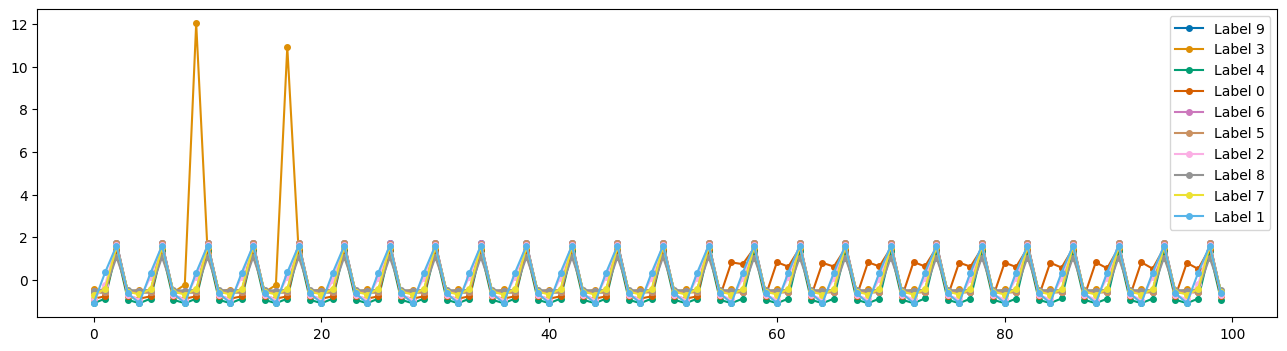

In [47]:
series = [train_x.iloc[np.random.randint(0, len(train_x)), 0][:100] for train_x in label_to_train_x.values()]
plot_series(*series, labels=[f"Label {label}" for label in label_to_train_x.keys()])

## Negative values ??

In [48]:
for idx, x in train_x.iterrows():
    series = x[0]
    contain_neg = len(series[series < 0]) > 0
    if not contain_neg:
        print(f"Series at index {idx} does not contain negative values.")

/tmp/ipykernel_341141/3269881955.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series = x[0]


**Comment**: all series contain negative values 

Quick Search:
> In the context of home energy monitoring and smart metering, negative appliance consumption indicates that the device is generating electricity rather than consuming it.

So is it really the case ??

## Seasonality

## Pick a random series ```s```

In [49]:
s = train_x.iloc[np.random.randint(0, N), 0][:50]

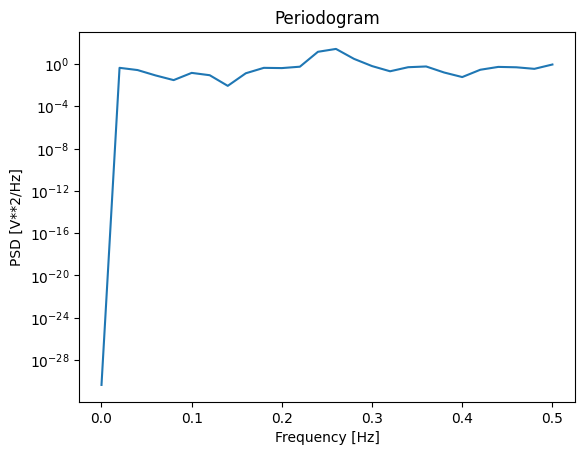

In [50]:
from scipy import signal
import matplotlib.pyplot as plt
f, Pxx = signal.periodogram(s, fs=1)

# 3. Plot
plt.figure()
plt.semilogy(f, Pxx)
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.title('Periodogram')
plt.show()

### Seasonal differencing (D = 1)

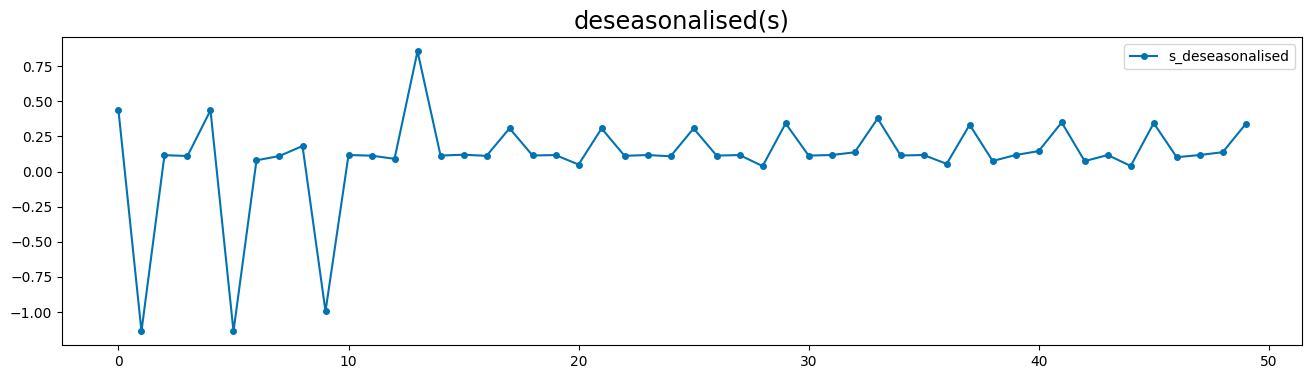

In [51]:
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(42)
seasonal_result = seasonal_decompose(s, period=4)
seasonal = seasonal_result.seasonal
s_deseasonalised = s - seasonal

_ = plot_series(s_deseasonalised, title="deseasonalised(s)", labels=["s_deseasonalised"])

# Submission

In [52]:
from sktime.datasets import load_arrow_head
from sktime.classification.kernel_based import RocketClassifier
from sklearn.metrics import accuracy_score
import os
import pandas as pd
import numpy as np


train_x, train_y = load_from_tsfile(os.path.join(DATA_DIR_PATH, "train.ts"))
test_x, _   = load_from_tsfile(os.path.join(DATA_DIR_PATH, "submission", "test.ts"))

# ROCKET: random convolutional kernels — state-of-the-art speed/accuracy tradeoff
clf = RocketClassifier(num_kernels=1000)
clf.fit(train_x, train_y)
# train accuracy
y_train_pred = clf.predict(train_x)
train_acc = accuracy_score(train_y, y_train_pred)
print(f"Train Accuracy: {train_acc:.4f}")
y_pred = clf.predict(test_x)
y_pred

Train Accuracy: 0.9400


array(['9', '9', '9', '9', '9', '9', '9', '9', '9', '9', '3', '3', '3',
       '8', '3', '3', '3', '3', '3', '3', '1', '4', '1', '1', '4', '4',
       '4', '4', '4', '4', '0', '0', '0', '0', '0', '4', '0', '0', '0',
       '0', '6', '6', '6', '6', '6', '6', '6', '2', '6', '6', '5', '5',
       '9', '5', '0', '9', '5', '5', '5', '5', '2', '2', '2', '2', '2',
       '5', '2', '2', '2', '2', '8', '8', '8', '8', '8', '8', '8', '8',
       '8', '8', '7', '9', '7', '8', '7', '7', '7', '7', '7', '7', '1',
       '5', '1', '1', '1', '2', '1', '1', '1', '1'], dtype='<U1')

In [53]:
submission_x, _ = load_from_tsfile(os.path.join(DATA_DIR_PATH, "submission", "test.ts"), return_data_type="numpy3d")
id_series = pd.read_csv(os.path.join(DATA_DIR_PATH, "submission", "id.csv"), header=None)
id_series.columns = ["Id"]
display(id_series)

,Id
0,ap1
1,ap2
2,ap3
3,ap4
4,ap5
...,...
95,ap96
96,ap97
97,ap98
98,ap99


In [54]:
y_pred_df = pd.DataFrame({
    "y_pred": y_pred
}, index=id_series["Id"])
y_pred_df

,y_pred
Id,
ap1,9
ap2,9
ap3,9
ap4,9
ap5,9
...,...
ap96,2
ap97,1
ap98,1


In [58]:
y_pred_df.to_csv(OUTPUT_PATH, index=True)
print(f"'y_pred' saved to: {OUTPUT_PATH}")

'y_pred' saved to: ./output/y_pred.csv
